# Plotting ERA5 data: Lakes

Here we plot many lake characteristics over Loktak Lake including lake bottom temperature, lake mix-layer depth, lake mix-layer temperature, lake shape factor, and lake total layer temperature.

------------------------------------------------------------------------------------

# Overview

The goal of this notebook is to continue the analysis started in the previous notebook (`notebook1.ipynb`) which was focused on ERA 5 data plotted over Manipur, India. In this notebook we will,
1. Import packages and access data
2. Slice the ERA 5 data
3. Plot the maps for lake characteristics

------------------------------------------------

# Importing packages and accessing data

The first thing to do when analyzing the lake characteristics data is to import the necessary packages, here we are looking to import xarray, numpy, matplotlib, cartopy, and metpy.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.units import units

Next we want to access the data, which we do through Earth Data Hub on Destination Earth. 

In [2]:
ds= xr.open_dataset(
    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-land-no-antartica-v0.zarr",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",
)

We next want to view the dataset to see the dimensions and data variables.

In [3]:
ds

<xarray.Dataset> Size: 705TB
Dimensions:              (valid_time: 664752, latitude: 1472, longitude: 3600)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 5MB 1950-01-01 ... 2025-...
  * latitude             (latitude) float64 12kB 90.0 89.9 89.8 ... -57.0 -57.1
  * longitude            (longitude) float64 29kB 0.0 0.1 0.2 ... 359.8 359.9
    depthBelowLandLayer  float64 8B ...
    number               int64 8B ...
    surface              float64 8B ...
Data variables: (12/50)
    asn                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    d2m                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    e                    (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    es                   (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    evabs                (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    evaow                (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    ...                   ...
    swvl4                (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    t2m                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    tp                   (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    tsn                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    u10                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    v10                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-10-29T11:44 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

# Slicing the data

Once we've looked at which variables we can choose from, we need to set the extent for the latitude and longitude for the region of interest. We set using the -180 to 180 scale and then we convert that into 360 degree scaling. Then we pick the target time using `np.datetime64` function. Then we pick the closest time ising the `.sel` function.

In [4]:
lonW=93
lonE= 95
latN=25
latS=24

if (lonW < 0 ):
    
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
target_time = np.datetime64("2023-07-02")
extent = [lonW, lonE, latN, latS]

# Find the closest time in the dataset
closest_time = ds['valid_time'].sel(valid_time=target_time, method='nearest').values



Now we can assign variables to the sections of data we want which are `lake bottom temperature (lbt)`, `lake mix-layer depth (mld)`, `lake mix-layer temperature (mlt)`, `lake shape factor (sf)`, and `lake total layer temperature (tt)`.

In [5]:
lbt = ds['lblt'].sel(valid_time=closest_time, method='nearest') #Lake bottom temperature
mld= ds['lmld'].sel(valid_time=closest_time, method='nearest') #Lake mix-layer depth
mlt= ds['lmlt'].sel(valid_time=closest_time, method='nearest') #Lake mix-layer temperature
sf= ds['lshf'].sel(valid_time=closest_time, method='nearest') #Lake shape factor
tt= ds['ltlt'].sel(valid_time=closest_time, method='nearest') #Lake total layer temperature


Next, 

In [8]:
lbt.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')
mld.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')
mlt.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')
sf.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')
tt.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')

<xarray.DataArray 'ltlt' (latitude: 32, longitude: 3600)> Size: 461kB
dask.array<getitem, shape=(32, 3600), dtype=float32, chunksize=(32, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude             (latitude) float64 256B 26.0 25.9 25.8 ... 23.0 22.9
  * longitude            (longitude) float64 29kB 0.0 0.1 0.2 ... 359.8 359.9
    depthBelowLandLayer  float64 8B ...
    number               int64 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B 2023-07-02
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1472
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           ltlt
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                Lake total layer temperature
    standard_name:                            unknown
    units:                                    K

Here we, select the lat and lon range using the `np.arange` function.

In [38]:
lat_range = np.arange(latS, latN,-0.1)
lon_range = np.arange(lonW, lonE,0.1)


Here we subset the data using the ranges selected above and using `method='nearest'` to get the points closest the those in the dataset for the desired range.

In [18]:
lbt_sub = lbt.sel(latitude=lat_range, method='nearest').sel(longitude=lon_range, method='nearest')
mld_sub= mld.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')
mlt_sub= mld.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')
sf_sub= mld.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')
tt_sub= mld.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')


# Plotting the maps

For some of these variables we need to convert from K to degrees celsius, we do this buy subtracting 273.15 from the data.

In [33]:
lbt_C= lbt_sub -273.15
mlt_C= mlt_sub -273.15
tt_C= tt_sub -273.15

We next want to print the shapes of lake bottom temperature with the latitiude and longitude ranges to ensure they match.

In [20]:
print("lbt_sub shape:", lbt_sub.shape)
print("lat shape:", len(lat_range))
print("lon shape:", len(lon_range))

lbt_sub shape: (10, 20)
lat shape: 10
lon shape: 20


Here we define the latitude and longitude for Loktak Lake to plot as a point later in the map.

In [21]:
lat_loktak = 24.5
lon_loktak = 93.8

We can now plot the map of Loktak Lake in Manipur, India. We first plot `lake bottom temperature`. We do this by defining the extent of the map and adding features like coastline, borders, land, ocean, and lakes. Then we can plot contours using levels and applying the latitude and longitude for the lake bottom temperature variable.

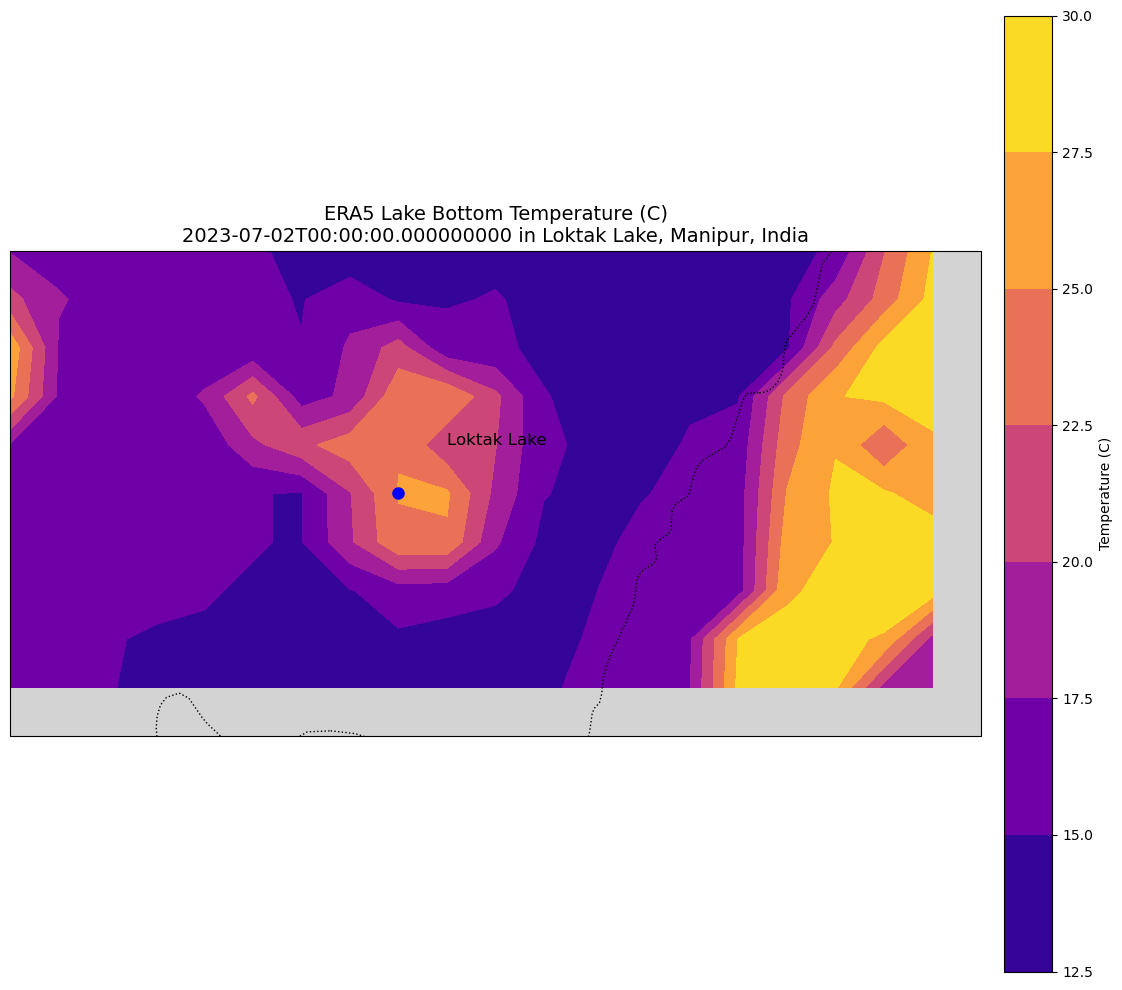

In [40]:
# Define map extent for Loktak Lake
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total lake bottom temperature
levels = np.linspace(0, np.max(lbt_sub.values), 20)
cf = ax.contourf(lbt_C['longitude'], lbt_C['latitude'], lbt_C.transpose('latitude', 'longitude'), cmap='plasma', transform=ccrs.PlateCarree())

# Add Loktak Lake point
ax.plot(lon_loktak, lat_loktak, marker='o', color='blue', markersize=8,
        transform=ccrs.PlateCarree(), label='Loktak Lake')

# Add label text (optional)
ax.text(lon_loktak + 0.1, lat_loktak + 0.1, 'Loktak Lake', fontsize=12,
        transform=ccrs.PlateCarree(), color='black')

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Temperature (C)")

# Title
plt.title(f"ERA5 Lake Bottom Temperature (C)\n{str(closest_time)} in Loktak Lake, Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


We next plot `lake mix-layer depth` using the same code as above but changing the variable name attached to latitude and longitude.

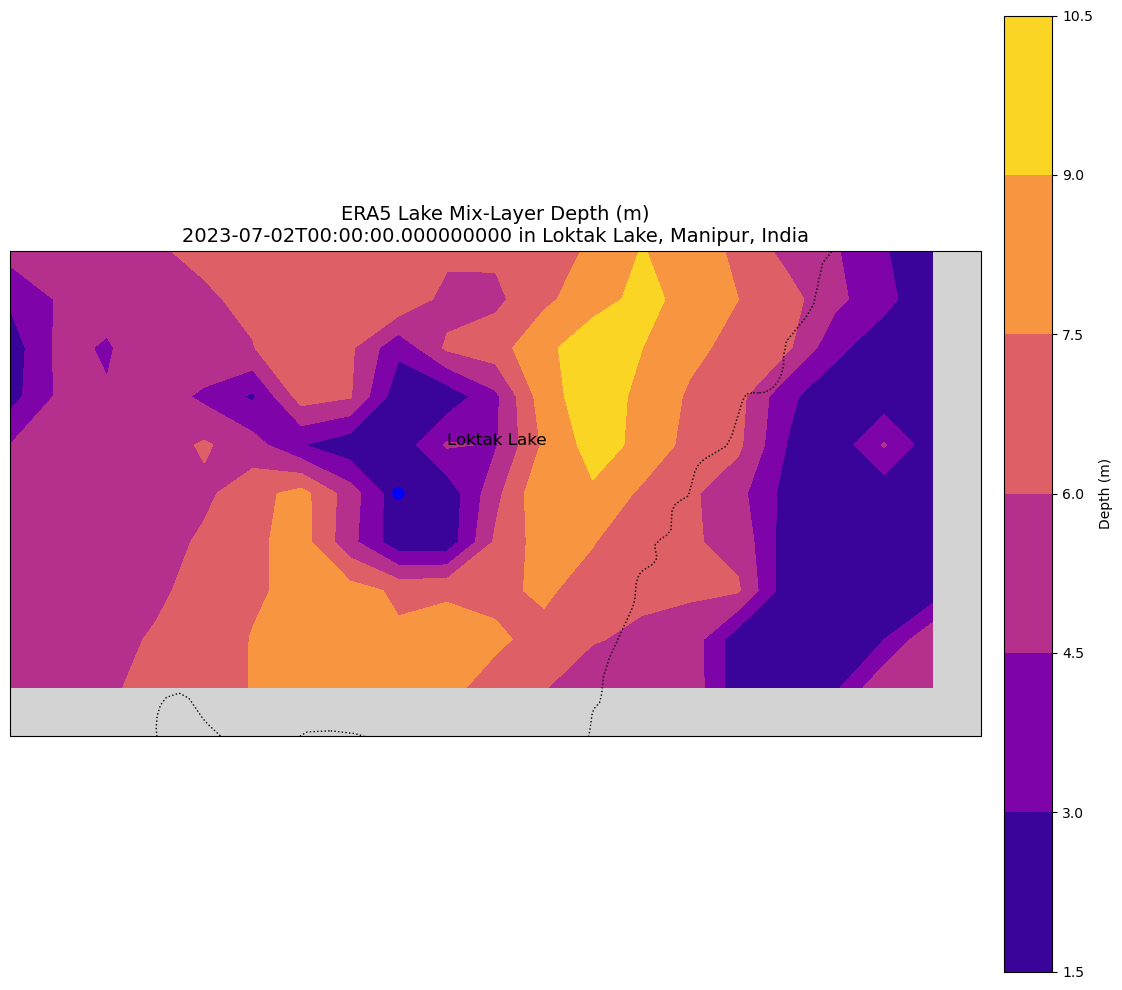

In [28]:
# Define map extent for Loktak Lake
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(0, np.max(lbt_sub.values), 20)
cf = ax.contourf(mld_sub['longitude'], mld_sub['latitude'], mld_sub.transpose('latitude', 'longitude'), cmap='plasma', transform=ccrs.PlateCarree())

# Add Loktak Lake point
ax.plot(lon_loktak, lat_loktak, marker='o', color='blue', markersize=8,
        transform=ccrs.PlateCarree(), label='Loktak Lake')

# Add label text (optional)
ax.text(lon_loktak + 0.1, lat_loktak + 0.1, 'Loktak Lake', fontsize=12,
        transform=ccrs.PlateCarree(), color='black')

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Depth (m)")

# Title
plt.title(f"ERA5 Lake Mix-Layer Depth (m)\n{str(closest_time)} in Loktak Lake, Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


Here we plot `lake mix-layer temperature`.

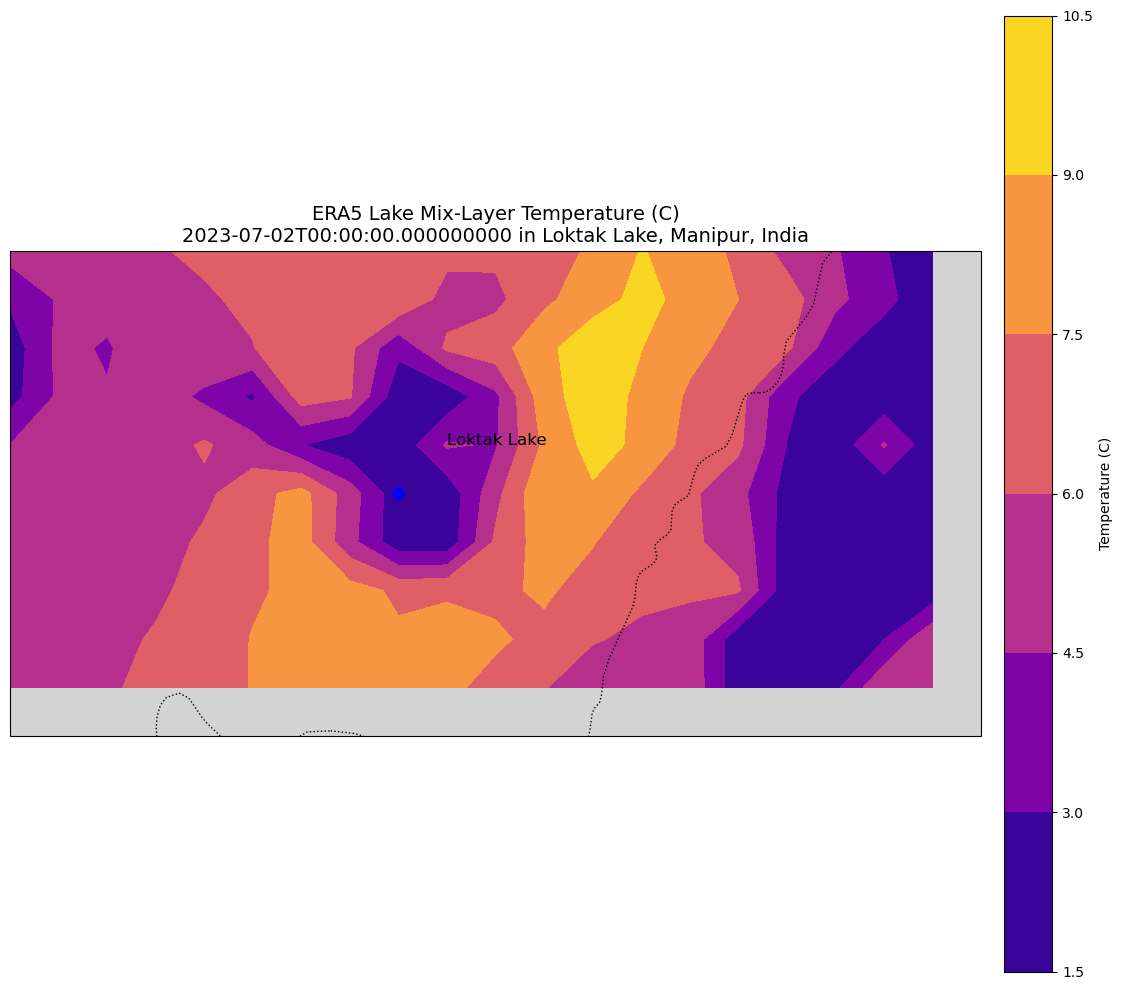

In [37]:
#slice the data based on latitude and longitude
#lbt_sub = lbt.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')

# Define map extent for Loktak Lake
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(0, np.max(lbt_sub.values), 20)
cf = ax.contourf(mlt_sub['longitude'], mlt_sub['latitude'], mlt_sub.transpose('latitude', 'longitude'), cmap='plasma', transform=ccrs.PlateCarree())

# Add Loktak Lake point
ax.plot(lon_loktak, lat_loktak, marker='o', color='blue', markersize=8,
        transform=ccrs.PlateCarree(), label='Loktak Lake')

# Add label text (optional)
ax.text(lon_loktak + 0.1, lat_loktak + 0.1, 'Loktak Lake', fontsize=12,
        transform=ccrs.PlateCarree(), color='black')

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Temperature (C)")

# Title
plt.title(f"ERA5 Lake Mix-Layer Temperature (C)\n{str(closest_time)} in Loktak Lake, Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


Now we can plot `lake shape factor`.

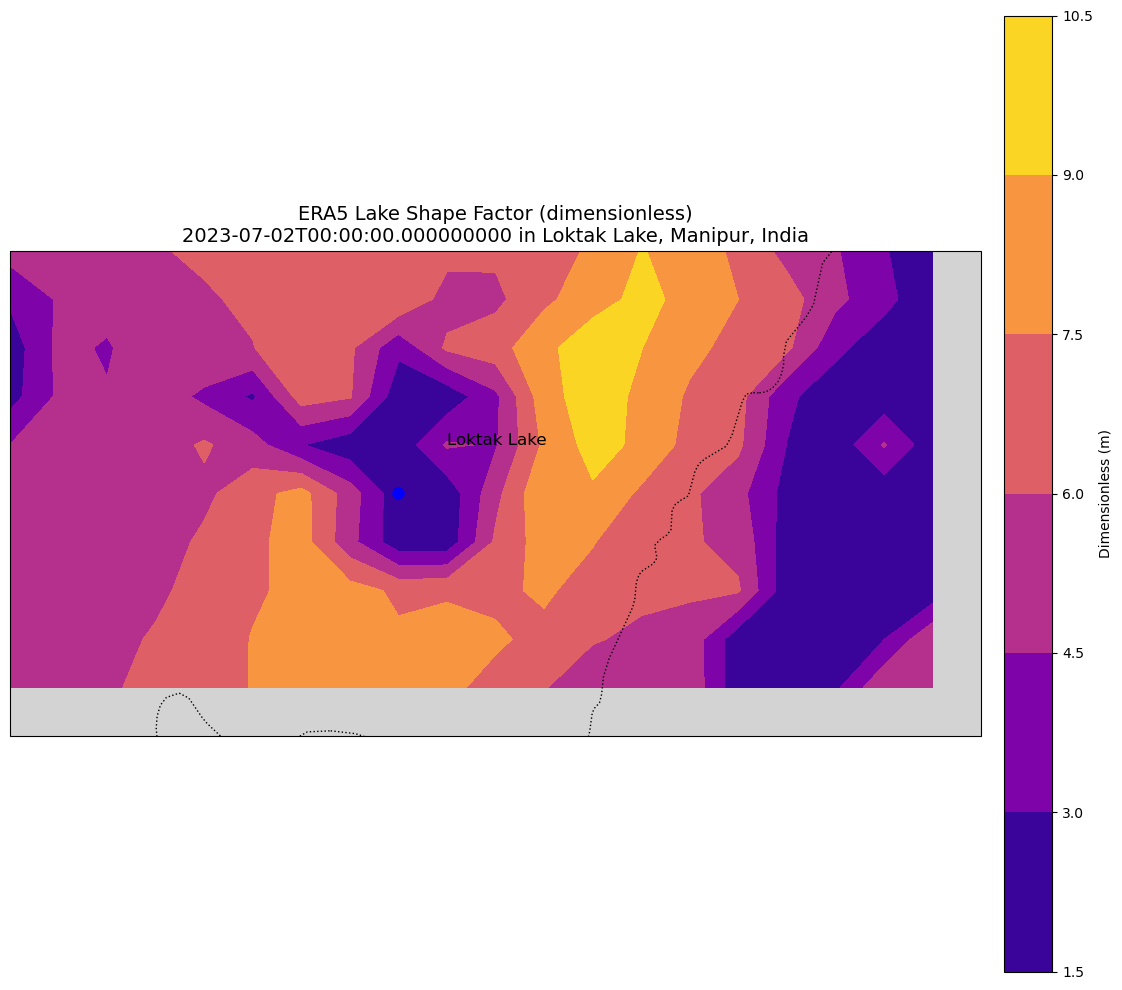

In [35]:
#slice the data based on latitude and longitude
#lbt_sub = lbt.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')

# Define map extent for Loktak Lake
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(0, np.max(lbt_sub.values), 20)
cf = ax.contourf(sf_sub['longitude'], sf_sub['latitude'], sf_sub.transpose('latitude', 'longitude'), cmap='plasma', transform=ccrs.PlateCarree())

# Add Loktak Lake point
ax.plot(lon_loktak, lat_loktak, marker='o', color='blue', markersize=8,
        transform=ccrs.PlateCarree(), label='Loktak Lake')

# Add label text (optional)
ax.text(lon_loktak + 0.1, lat_loktak + 0.1, 'Loktak Lake', fontsize=12,
        transform=ccrs.PlateCarree(), color='black')

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Dimensionless (m)")

# Title
plt.title(f"ERA5 Lake Shape Factor (dimensionless)\n{str(closest_time)} in Loktak Lake, Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


Lastly, we plot `lake total layer temperature`.

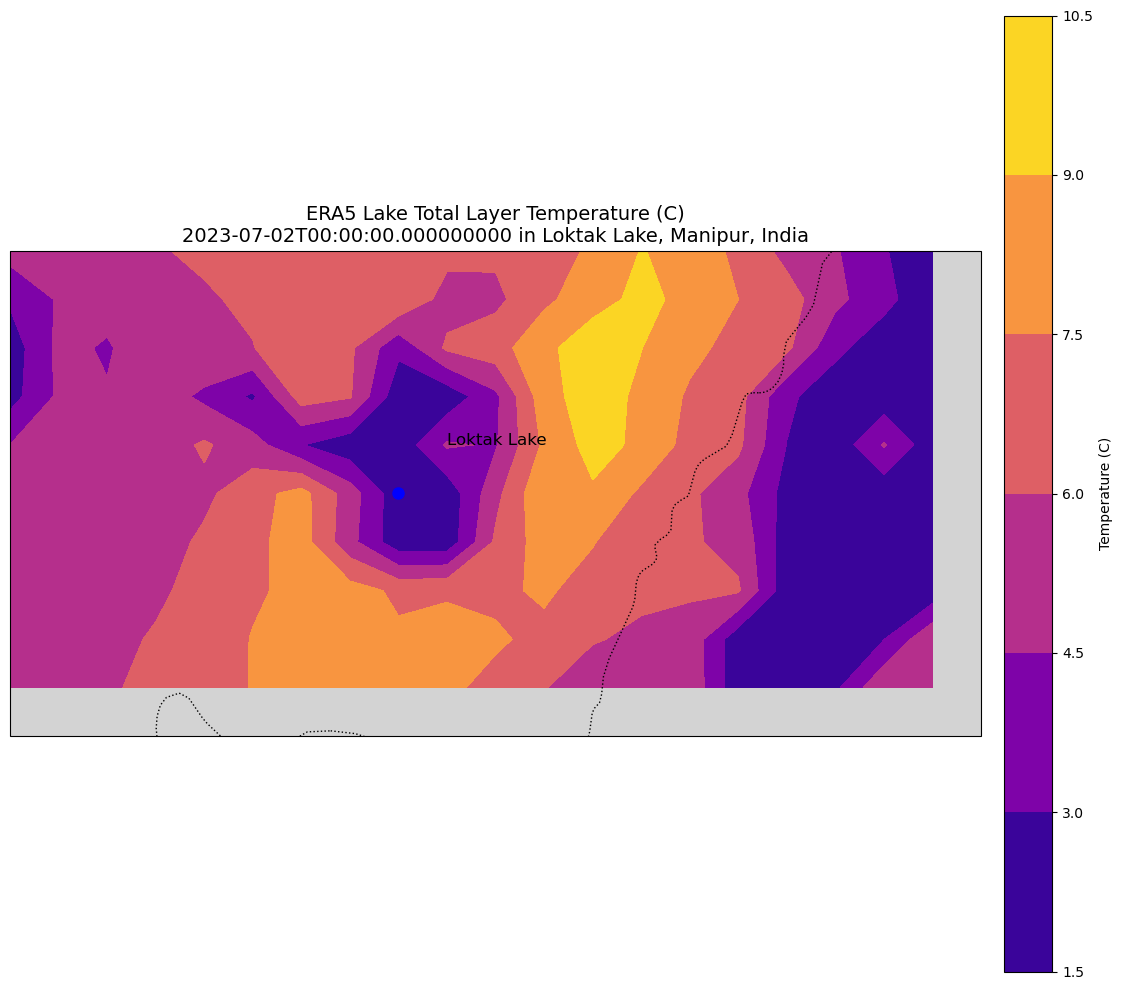

In [39]:
#slice the data based on latitude and longitude
#lbt_sub = lbt.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')

# Define map extent for Loktak Lake
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(0, np.max(lbt_sub.values), 20)
cf = ax.contourf(tt_sub['longitude'], tt_sub['latitude'], tt_sub.transpose('latitude', 'longitude'), cmap='plasma', transform=ccrs.PlateCarree())

# Add Loktak Lake point
ax.plot(lon_loktak, lat_loktak, marker='o', color='blue', markersize=8,
        transform=ccrs.PlateCarree(), label='Loktak Lake')

# Add label text (optional)
ax.text(lon_loktak + 0.1, lat_loktak + 0.1, 'Loktak Lake', fontsize=12,
        transform=ccrs.PlateCarree(), color='black')

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Temperature (C)")

# Title
plt.title(f"ERA5 Lake Total Layer Temperature (C)\n{str(closest_time)} in Loktak Lake, Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


#  Summary

In this notebook we have:
- Imported necessary packages
- Accessed the ERA 5 from Destination Earth
- Defined the latitude and longitude of the map
- Selecting slices of longitude and latitude from the data
- Plotted maps of lake bottom temperature, lake mix-layer depth, lake mix-layer temperature, lake shape factor, and lake total layer temperature.


After plotting precipitation, evaporation, and runoff in the previous notebook (`notebook2.ipynb`), we can look at these together to evaluate the climate in India and how it affects lakes.